In [50]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [51]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="optuna.distributions")

In [52]:
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.training import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    compare_models_pairwise_r2,
    journal_plot_pack,
)
from src.train.poisson_nn.nn_models import CNNExtractor, RNNExtractor
from sklearn.preprocessing import StandardScaler

In [53]:
BASE_MODEL_DIR = "../resources/models/simulated"
BASE_RESULTS_DIR = "../resources/results/simulated"
FORCE_EXPERIMENTS = (
    True  # set to True to re-run all experiments and overwrite existing results/models
)

filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../resources/data/simulated", filenames)

In [54]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

### Baseline models (GLM and XGBoost)

In [55]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\GLM.pkl


In [56]:
# Fit without grid search
glm_nogs_results = run_experiment(
    "GLM-NoGS",
    fit_poisson_glm,
    {"grid_search": False, "alpha": 0.1},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\GLM-NoGS.pkl


In [57]:
glm_results["best_params"]

{0.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 1.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 2.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 3.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 4.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 10.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 11.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 12.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 13.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 14.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 25.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 26.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 27.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 28.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 29.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 45.0: {'model_params': {'alpha': 0.01}, 'tra

In [58]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\XGBoost.pkl


In [59]:
# Poisson XGBoost without grid search
xgboost_nogs_results = run_experiment(
    "XGBoost-NoGS",
    fit_poisson_xgboost,
    {"grid_search": False},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\XGBoost-NoGS.pkl


In [60]:
xgboost_results["best_params"]

{0.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 1.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 2.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 3.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 4.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 10.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 11.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 12.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 13.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estim

### Extractor factory

In [61]:
def make_extractor(extractor_name, n_features, hidden_sizes):
    """
    Factory function for creating feature extractors with a unified interface.

    Parameters
    ----------
    extractor_name : str
        One of {"MLP", "CNN", "RNN"}.
    n_features : int
        Number of input features.
    hidden_sizes : int or sequence of int
        Controls the depth/width of the extractor:
        - CNN: hidden_channels per conv layer
        - RNN: hidden_sizes per GRU layer
        - MLP: ignored (returns None)

    Returns
    -------
    nn.Module or None
        The extractor module, or None for MLP-based shared layers.
    """

    if extractor_name == "CNN":
        return CNNExtractor(
            n_features=n_features,
            hidden_channels=hidden_sizes,
            kernel=3,
            dropout=0.1,
        )

    elif extractor_name == "RNN":
        return RNNExtractor(
            n_features=n_features,
            hidden_sizes=hidden_sizes,
            dropout=0.1,
        )

    elif extractor_name == "MLP":
        return None

    else:
        raise ValueError(f"Unknown extractor_name: {extractor_name}")


extractor_names = ["MLP", "CNN", "RNN"]

### Per-cell Neural Networks (MLP + CNN + RNN, GS + No-GS)

In [62]:
nn_model_param_grid_base = {
    "hidden_sizes": [
        (32,),
        (64,),
        (64, 32),
    ]
}

nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

percell_results = {name: {} for name in extractor_names}

# Grid-search versions
for name in extractor_names:
    print(f"\n=== Per-Cell NN (GS) with {name} extractor ===")

    # For CNN/RNN, we will build extractors inside the grid
    if name == "MLP":
        model_param_grid = nn_model_param_grid_base

    else:
        model_param_grid = {
            "extractor": [
                make_extractor(name, X.shape[0], hs)
                for hs in nn_model_param_grid_base["hidden_sizes"]
            ],
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-PerCell-{name}",
        fit_poisson_nn,
        {
            "batch_size": "auto",
            "epochs": 30,
            "grid_search": True,
            "k_folds": 2,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": nn_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["GS"] = res


=== Per-Cell NN (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [32, 16]
k_folds: 2
lr (default): 0.001
epochs (default): 30
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15


=== Starting per-cell grid search ===
model_param_grid= {'hidden_sizes': [(32,), (64,), (64, 32)]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001, 0.001]}

Refitting final models with best hyperparameters for a total of 20 cells...
Cell 0.0 refit took 38.25s
Cell 1.0 refit took 43.01s
Cell 2.0 refit took 43.54s
Cell 3.0 refit took 37.55s
Cell 4.0 refit took 43.68s
Cell 10.0 refit took 43.91s
Cell 11.0 refit took 45.21s
Cell 12.0 refit took 44.86s
Cell 13.0 refit took 44.65s
Cell 14.0 refit took 44.77s
Cell 25.0 refit took 43.87s
Cell 26.0 refit took 48.05s
Cell 27.0 refit took 51.96s
Cell 28.0 refit took 51.22s
Cell 29.0 refit took 51.63s
Cell 45.0 refit took 51.05s
Cell 46.0 refit took


(process:35112): Pango-WARNING **: 11:23:51.899: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Architecture diagram saved to ..\resources\results\simulated\NN-PerCell-MLP\architecture.png

=== Per-Cell NN (GS) with CNN extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [32, 16]
k_folds: 2
lr (default): 0.001
epochs (default): 30
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15


=== Starting per-cell grid search ===
model_param_grid= {'extractor': [CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
  )
), CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=T


(process:34852): Pango-WARNING **: 11:50:52.759: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Architecture diagram saved to ..\resources\results\simulated\NN-PerCell-CNN\architecture.png

=== Per-Cell NN (GS) with RNN extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [32, 16]
k_folds: 2
lr (default): 0.001
epochs (default): 30
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15


=== Starting per-cell grid search ===
model_param_grid= {'extractor': [RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 32, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 64, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 64, batch_first=True, dropout=0.1)
    (1): GRU(64, 32, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
)], 'hidden_sizes'


(process:33076): Pango-WARNING **: 12:37:48.657: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Architecture diagram saved to ..\resources\results\simulated\NN-PerCell-RNN\architecture.png


In [63]:
# Fixed hidden sizes for No-GS runs
fixed_hidden_sizes = (64, 32)

# No-grid-search versions (fixed extractor)
for name in extractor_names:
    print(f"\n=== Per-Cell NN (No GS) with {name} extractor ===")

    # Build extractor using the new unified interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_hidden_sizes
    )

    if extractor is None:
        # MLP baseline: use hidden_sizes directly in the model
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": fixed_hidden_sizes,
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }

    else:
        # CNN/RNN: fixed extractor, no grid search
        kwargs = {
            "batch_size": "auto",
            "model_param_grid": {
                "extractor": extractor,
                "hidden_sizes": [None],
            },
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-PerCell-{name}-NoGS",
        fit_poisson_nn,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["NoGS"] = res


=== Per-Cell NN (No GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: (64, 32)
k_folds: 3
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15

Preparing datasets with train_frac=0.7, val_frac=0.15, use_val=True

=== Using the following hyperparameters (NO GRID SEARCH) ===
Model params: {'hidden_sizes': (64, 32), 'extractor': None}
Trainer params: {'lr': 0.001, 'epochs': 100, 'weight_decay': 0.0001, 'l1_lambda': 0.0, 'batch_size': 'auto', 'patience': 10}


=== Network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]             384
              ReLU-2                   [-1, 64]               0
            Linear-3                   [-1, 32]           2,080
              ReLU-4    


(process:37312): Pango-WARNING **: 12:38:40.014: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Architecture diagram saved to ..\resources\results\simulated\NN-PerCell-MLP-NoGS\architecture.png

=== Per-Cell NN (No GS) with CNN extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [32, 16]
k_folds: 3
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15

Preparing datasets with train_frac=0.7, val_frac=0.15, use_val=True

=== Using the following hyperparameters (NO GRID SEARCH) ===
Model params: {'extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.


(process:22720): Pango-WARNING **: 12:40:06.370: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Architecture diagram saved to ..\resources\results\simulated\NN-PerCell-CNN-NoGS\architecture.png

=== Per-Cell NN (No GS) with RNN extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [32, 16]
k_folds: 3
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
train_frac: 0.7
val_frac: 0.15

Preparing datasets with train_frac=0.7, val_frac=0.15, use_val=True

=== Using the following hyperparameters (NO GRID SEARCH) ===
Model params: {'extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 64, batch_first=True, dropout=0.1)
    (1): GRU(64, 32, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
), 'hidden_sizes': [None]}
Trainer params: {'lr': 0.001, 'epochs': 100, 'weight_decay': 0.0001, 'l1_lambda': 0.0, 'batch_size': 'auto', 'patience': 10}


=== Network architecture summary ===
----------------------------------------------


(process:15552): Pango-WARNING **: 12:41:53.527: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


Architecture diagram saved to ..\resources\results\simulated\NN-PerCell-RNN-NoGS\architecture.png


In [64]:
tl_results = {
    "deep_shared_shallow_head": {name: {} for name in extractor_names},
    "deep_shared_deep_head": {name: {} for name in extractor_names},
    "shallow_shared_deep_head": {name: {} for name in extractor_names},
}

### Transfer Learning: deep shared hidden and shallow cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [65]:
# Updated hidden-size grid for deep shared extractor
tl_deep_shared_shallow_head_model_param_grid_base = {
    "hidden_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ]
}

tl_deep_shared_shallow_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Shared hidden: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # For CNN/RNN: hidden_sizes define extractor depth
    # For MLP: extractor = None
    extractor_list = []
    for hs in tl_deep_shared_shallow_head_model_param_grid_base["hidden_sizes"]:
        extractor_list.append(
            make_extractor(extractor_name=name, n_features=X.shape[0], hidden_sizes=hs)
        )

    if name == "MLP":
        # MLP baseline: no extractor, hidden_sizes define shared MLP
        model_param_grid = {
            "hidden_sizes": tl_deep_shared_shallow_head_model_param_grid_base[
                "hidden_sizes"
            ],
            "shared_extractor": [None],
        }
    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_shallow_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["GS"] = res


=== TL DeepSharedShallowHead (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'hidden_sizes': [(128,), (256,), (128, 64), (256, 128)], 'shared_extractor': [None]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}


===== NN-DeepSharedShallowHead-TL-MLP Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5794
Test log-likelihood:   3487.71
Test deviance:         6.38

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5709
Test log-likelihood:   3267.26
Test deviance:         6.34

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'hidden_sizes': [None], 'shared_extractor': [RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
    (1): GRU(128, 64, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
    (1): GRU(256, 128, batch_first=True, drop

In [66]:
# Fixed hidden sizes for No-GS TL run
fixed_hidden_sizes = (256, 128)

# Shared hidden: No-GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_hidden_sizes
    )

    if extractor is None:
        # MLP baseline: shared MLP uses hidden_sizes directly
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": fixed_hidden_sizes,
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }

    else:
        # CNN/RNN: use extractor as shared feature extractor
        kwargs = {
            "batch_size": "auto",
            "model_params": {
                "shared_extractor": extractor,
                "hidden_sizes": [None],  # ignored for CNN/RNN, but required for MLP
            },
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["NoGS"] = res


=== TL DeepSharedShallowHead (No GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: (256, 128)
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0001
batch_size (default): auto
patience (default): 10
agg_method: median

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]           1,536
              ReLU-2                  [-1, 256]               0
            Linear-3                  [-1, 128]          32,896
              ReLU-4                  [-1, 128]               0
            Linear-5                    [-1, 1]             129
          Softplus-6                    [-1, 1]               0
DeepSharedShallowHeadPoissonNN-7                       [-1]               0
Total params: 34,561
Trainable par

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



===== NN-DeepSharedShallowHead-TL-RNN-NoGS Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3079
Test log-likelihood:   2561.47
Test deviance:         10.49

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3469
Test log-likelihood:   2522.57
Test deviance:         9.65

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3158
Test log-likelihood:   2205.96
Test deviance:         9.55

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3276
Test log-likelihood:   2387.72
Test deviance:         9.68

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3262
Test log-likelihood:   2508.13
Test deviance:         9.93

--- Cell 10.0 -

### Transfer Learning: deep shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [67]:
tl_deep_shared_deep_head_model_param_grid_base = {
    "shared_sizes": [
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_deep_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Nonlinear heads: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_sizes configuration
    extractor_list = []
    for shared_sizes in tl_deep_shared_deep_head_model_param_grid_base["shared_sizes"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name, n_features=X.shape[0], hidden_sizes=shared_sizes
            )
        )

    if name == "MLP":
        # MLP baseline: shared MLP uses shared_sizes directly
        model_param_grid = {
            "shared_sizes": tl_deep_shared_deep_head_model_param_grid_base[
                "shared_sizes"
            ],
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "shared_extractor": extractor_list,
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_sizes": [None],  # ignored for CNN/RNN, but required for MLP
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "deep_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["GS"] = res


=== TL DeepSharedDeepHead (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'shared_sizes': [(128,), (256,), (128, 64), (256, 128)], 'head_sizes': [(64, 32), (128, 64), (256, 128)], 'shared_extractor': [None]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}


===== NN-DeepSharedDeepHead-TL-MLP Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8870
Test log-likelihood:   4537.28
Test deviance:         1.71

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8819
Test log-likelihood:   4301.01
Test deviance:         1.74

--- Cell 2.0 ---
Train metrics:         

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



===== NN-DeepSharedDeepHead-TL-RNN Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9118
Test log-likelihood:   4621.93
Test deviance:         1.34

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9114
Test log-likelihood:   4398.99
Test deviance:         1.31

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8988
Test log-likelihood:   4037.47
Test deviance:         1.41

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9235
Test log-likelihood:   4318.11
Test deviance:         1.10

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9120
Test log-likelihood:   4450.81
Test deviance:         1.30

--- Cell 10.0 ---
Train 

In [68]:
# Fixed sizes for No-GS TL DeepSharedDeepHead
fixed_shared_sizes = (256, 128)
fixed_head_sizes = (128, 64)

# Nonlinear heads: No-GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_shared_sizes
    )

    if extractor is None:
        # MLP baseline: shared MLP uses shared_sizes directly
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "deep_shared_deep_head",
            "model_params": {
                "shared_sizes": fixed_shared_sizes,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "deep_shared_deep_head",
            "model_params": {
                "shared_sizes": None,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["NoGS"] = res


=== TL DeepSharedDeepHead (No GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0001
batch_size (default): auto
patience (default): 10
agg_method: median

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]              96
              ReLU-2                   [-1, 16]               0
            Linear-3                   [-1, 32]             544
              ReLU-4                   [-1, 32]               0
            Linear-5                   [-1, 16]             528
              ReLU-6                   [-1, 16]               0
            Linear-7                    [-1, 1]              17
          Softplus-8                    [-1, 1]        

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0001
batch_size (default): auto
patience (default): 10
agg_method: median

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
               GRU-1  [[-1, 5, 256], [-1, 2, 256]]               0
               GRU-2  [[-1, 5, 128], [-1, 2, 128]]               0
         LayerNorm-3               [-1, 5, 128]             256
      RNNExtractor-4                  [-1, 128]               0
            Linear-5                   [-1, 32]           4,128
              ReLU-6                   [-1, 32]               0
            Linear-7                   [-1, 16]             528
              ReLU-8                   [-1, 16]               0
            Linear-9                    [-1

### Transfer Learning: shallow shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [69]:
tl_shallow_shared_deep_head_model_param_grid_base = {
    "shared_dim": [128, 256],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_shallow_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# First layer: GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_dim
    extractor_list = []
    for sd in tl_shallow_shared_deep_head_model_param_grid_base["shared_dim"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name,
                n_features=X.shape[0],
                hidden_sizes=(sd,),  # shallow extractor = 1 layer
            )
        )

    if name == "MLP":
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        model_param_grid = {
            "shared_dim": tl_shallow_shared_deep_head_model_param_grid_base[
                "shared_dim"
            ],
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        model_param_grid = {
            "shared_dim": [None],  # ignored for CNN/RNN, but required for MLP
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shallow_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_shallow_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["GS"] = res


=== TL ShallowSharedDeepHead (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'shared_dim': [128, 256], 'head_sizes': [(64, 32), (128, 64), (256, 128)], 'shared_extractor': [None]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}


===== NN-ShallowSharedDeepHead-TL-MLP Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8694
Test log-likelihood:   4477.25
Test deviance:         1.98

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8582
Test log-likelihood:   4222.29
Test deviance:         2.09

--- Cell 2.0 ---
Train metrics:         (not available)
Val metri

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



===== NN-ShallowSharedDeepHead-TL-RNN Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8894
Test log-likelihood:   4545.38
Test deviance:         1.68

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8834
Test log-likelihood:   4305.89
Test deviance:         1.72

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8803
Test log-likelihood:   3979.08
Test deviance:         1.67

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8938
Test log-likelihood:   4221.81
Test deviance:         1.53

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8838
Test log-likelihood:   4357.13
Test deviance:         1.71

--- Cell 10.0 ---
Tra

In [70]:
# Fixed sizes for No-GS TL ShallowSharedDeepHead
fixed_shared_dim = 128
fixed_head_sizes = (128, 64)

# First layer: No-GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # Shallow extractor = one layer → hidden_sizes = (shared_dim,)
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=(fixed_shared_dim,)
    )

    if extractor is None:
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shallow_shared_deep_head",
            "model_params": {
                "shared_dim": fixed_shared_dim,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shallow_shared_deep_head",
            "model_params": {
                "shared_dim": None,  # ignored for CNN/RNN, but required for MLP
                "head_sizes": fixed_head_sizes,
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["NoGS"] = res


=== TL ShallowSharedDeepHead (No GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0001
batch_size (default): auto
patience (default): 10
agg_method: median

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]              96
              ReLU-2                   [-1, 16]               0
            Linear-3                   [-1, 32]             544
              ReLU-4                   [-1, 32]               0
            Linear-5                   [-1, 16]             528
              ReLU-6                   [-1, 16]               0
            Linear-7                    [-1, 1]              17
          Softplus-8                    [-1, 1]     

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



===== NN-ShallowSharedDeepHead-TL-RNN-NoGS Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5988
Test log-likelihood:   3553.95
Test deviance:         6.08

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.6106
Test log-likelihood:   3399.20
Test deviance:         5.75

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.6292
Test log-likelihood:   3190.62
Test deviance:         5.18

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.6260
Test log-likelihood:   3354.40
Test deviance:         5.38

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.6188
Test log-likelihood:   3478.24
Test deviance:         5.62

--- Cell 10.0 --

In [71]:
print("MLP\n", percell_results["MLP"]["GS"]["best_params"])
print("CNN\n", percell_results["CNN"]["GS"]["best_params"])
print("RNN\n", percell_results["RNN"]["GS"]["best_params"])

MLP
 {0.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0}}, 1.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 2.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 3.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0}}, 4.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 10.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 11.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 1e-05}}, 12.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.0001}}, 13.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 14.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lambda': 0.001}}, 25.0: {'model_params': {'hidden_sizes': (64, 32)}, 'trainer_params': {'l1_lamb

In [72]:
print("MLP\n", tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'hidden_sizes': (256, 128), 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 0.0001}}
CNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'hidden_sizes': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05

In [73]:
print("MLP\n", tl_results["deep_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["deep_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["deep_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': None, 'shared_sizes': (256, 128)}, 'trainer_params': {'l1_lambda': 0.0}}
CNN
 {'model_params': {'head_sizes': (256, 128), 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(256, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
), 'shared_sizes': None}, 'trainer_params': {'l1_lambda': 1e-05}}
RNN
 {'model_params': {'head_sizes': (128, 64), 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dro

In [74]:
print("MLP\n", tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["best_params"])
print("CNN\n", tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["best_params"])
print("RNN\n", tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["best_params"])

MLP
 {'model_params': {'head_sizes': (256, 128), 'shared_dim': 256, 'shared_extractor': None}, 'trainer_params': {'l1_lambda': 0.0}}
CNN
 {'model_params': {'head_sizes': (256, 128), 'shared_dim': None, 'shared_extractor': CNNExtractor(
  (conv): Sequential(
    (0): Conv1d(1, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (adapter): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
  )
)}, 'trainer_params': {'l1_lambda': 0.0001}}
RNN
 {'model_params': {'head_sizes': (256, 128), 'shared_dim': None, 'shared_extractor': RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 256, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
)}, 'trainer_params': {'l1_lambda': 0.0001}}


### Build comparison lists for GS and No-GS

In [75]:
# Grid search results for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN",
    ),
]

cells_gs = sorted(glm_results["results"].keys())

In [76]:
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_gs = pd.DataFrame(data_rows)
df_test_perf_gs

,cell,GLM,XGBoost,NN-PerCell-MLP,NN-PerCell-CNN,NN-PerCell-RNN,NN-DeepSharedShallowHead-TL-MLP,NN-DeepSharedShallowHead-TL-CNN,NN-DeepSharedShallowHead-TL-RNN,NN-DeepSharedDeepHead-TL-MLP,NN-DeepSharedDeepHead-TL-CNN,NN-DeepSharedDeepHead-TL-RNN,NN-ShallowSharedDeepHead-TL-MLP,NN-ShallowSharedDeepHead-TL-CNN,NN-ShallowSharedDeepHead-TL-RNN
0,0.0,0.513104,0.753915,0.881525,0.818835,0.861255,0.579365,0.759967,0.586349,0.887030,0.896795,0.911843,0.869432,0.602533,0.889404
1,1.0,0.507823,0.736288,0.871935,0.820681,0.872139,0.570893,0.761137,0.600535,0.881888,0.899805,0.911367,0.858207,0.613671,0.883359
2,2.0,0.516779,0.752605,0.828639,0.851436,0.882372,0.601825,0.785183,0.608220,0.872274,0.891572,0.898844,0.858291,0.600423,0.880253
3,3.0,0.498979,0.769270,0.881145,0.866152,0.909692,0.598874,0.775888,0.610262,0.893690,0.909383,0.923490,0.885992,0.623278,0.893766
4,4.0,0.503240,0.753150,0.866796,0.873272,0.891721,0.577313,0.767910,0.597716,0.886538,0.899374,0.912040,0.862826,0.609293,0.883792
5,10.0,0.410530,0.677540,0.783448,0.763013,0.765939,0.503774,0.678429,0.656224,0.759938,0.784481,0.764792,0.753747,0.523337,0.750847
6,11.0,0.428363,0.693149,0.771285,0.774863,0.765846,0.509285,0.672498,0.652448,0.768647,0.786948,0.776293,0.761755,0.501289,0.762293
7,12.0,0.468006,0.713012,0.794835,0.770807,0.783796,0.538603,0.713179,0.665697,0.770924,0.788338,0.783556,0.778112,0.447120,0.761088
8,13.0,0.448544,0.703250,0.801722,0.773750,0.796018,0.527534,0.712971,0.653767,0.773160,0.794910,0.780735,0.773561,0.460381,0.760875
9,14.0,0.425316,0.675299,0.754625,0.734952,0.767167,0.528304,0.680127,0.658981,0.746045,0.767725,0.761782,0.734132,0.498997,0.734357


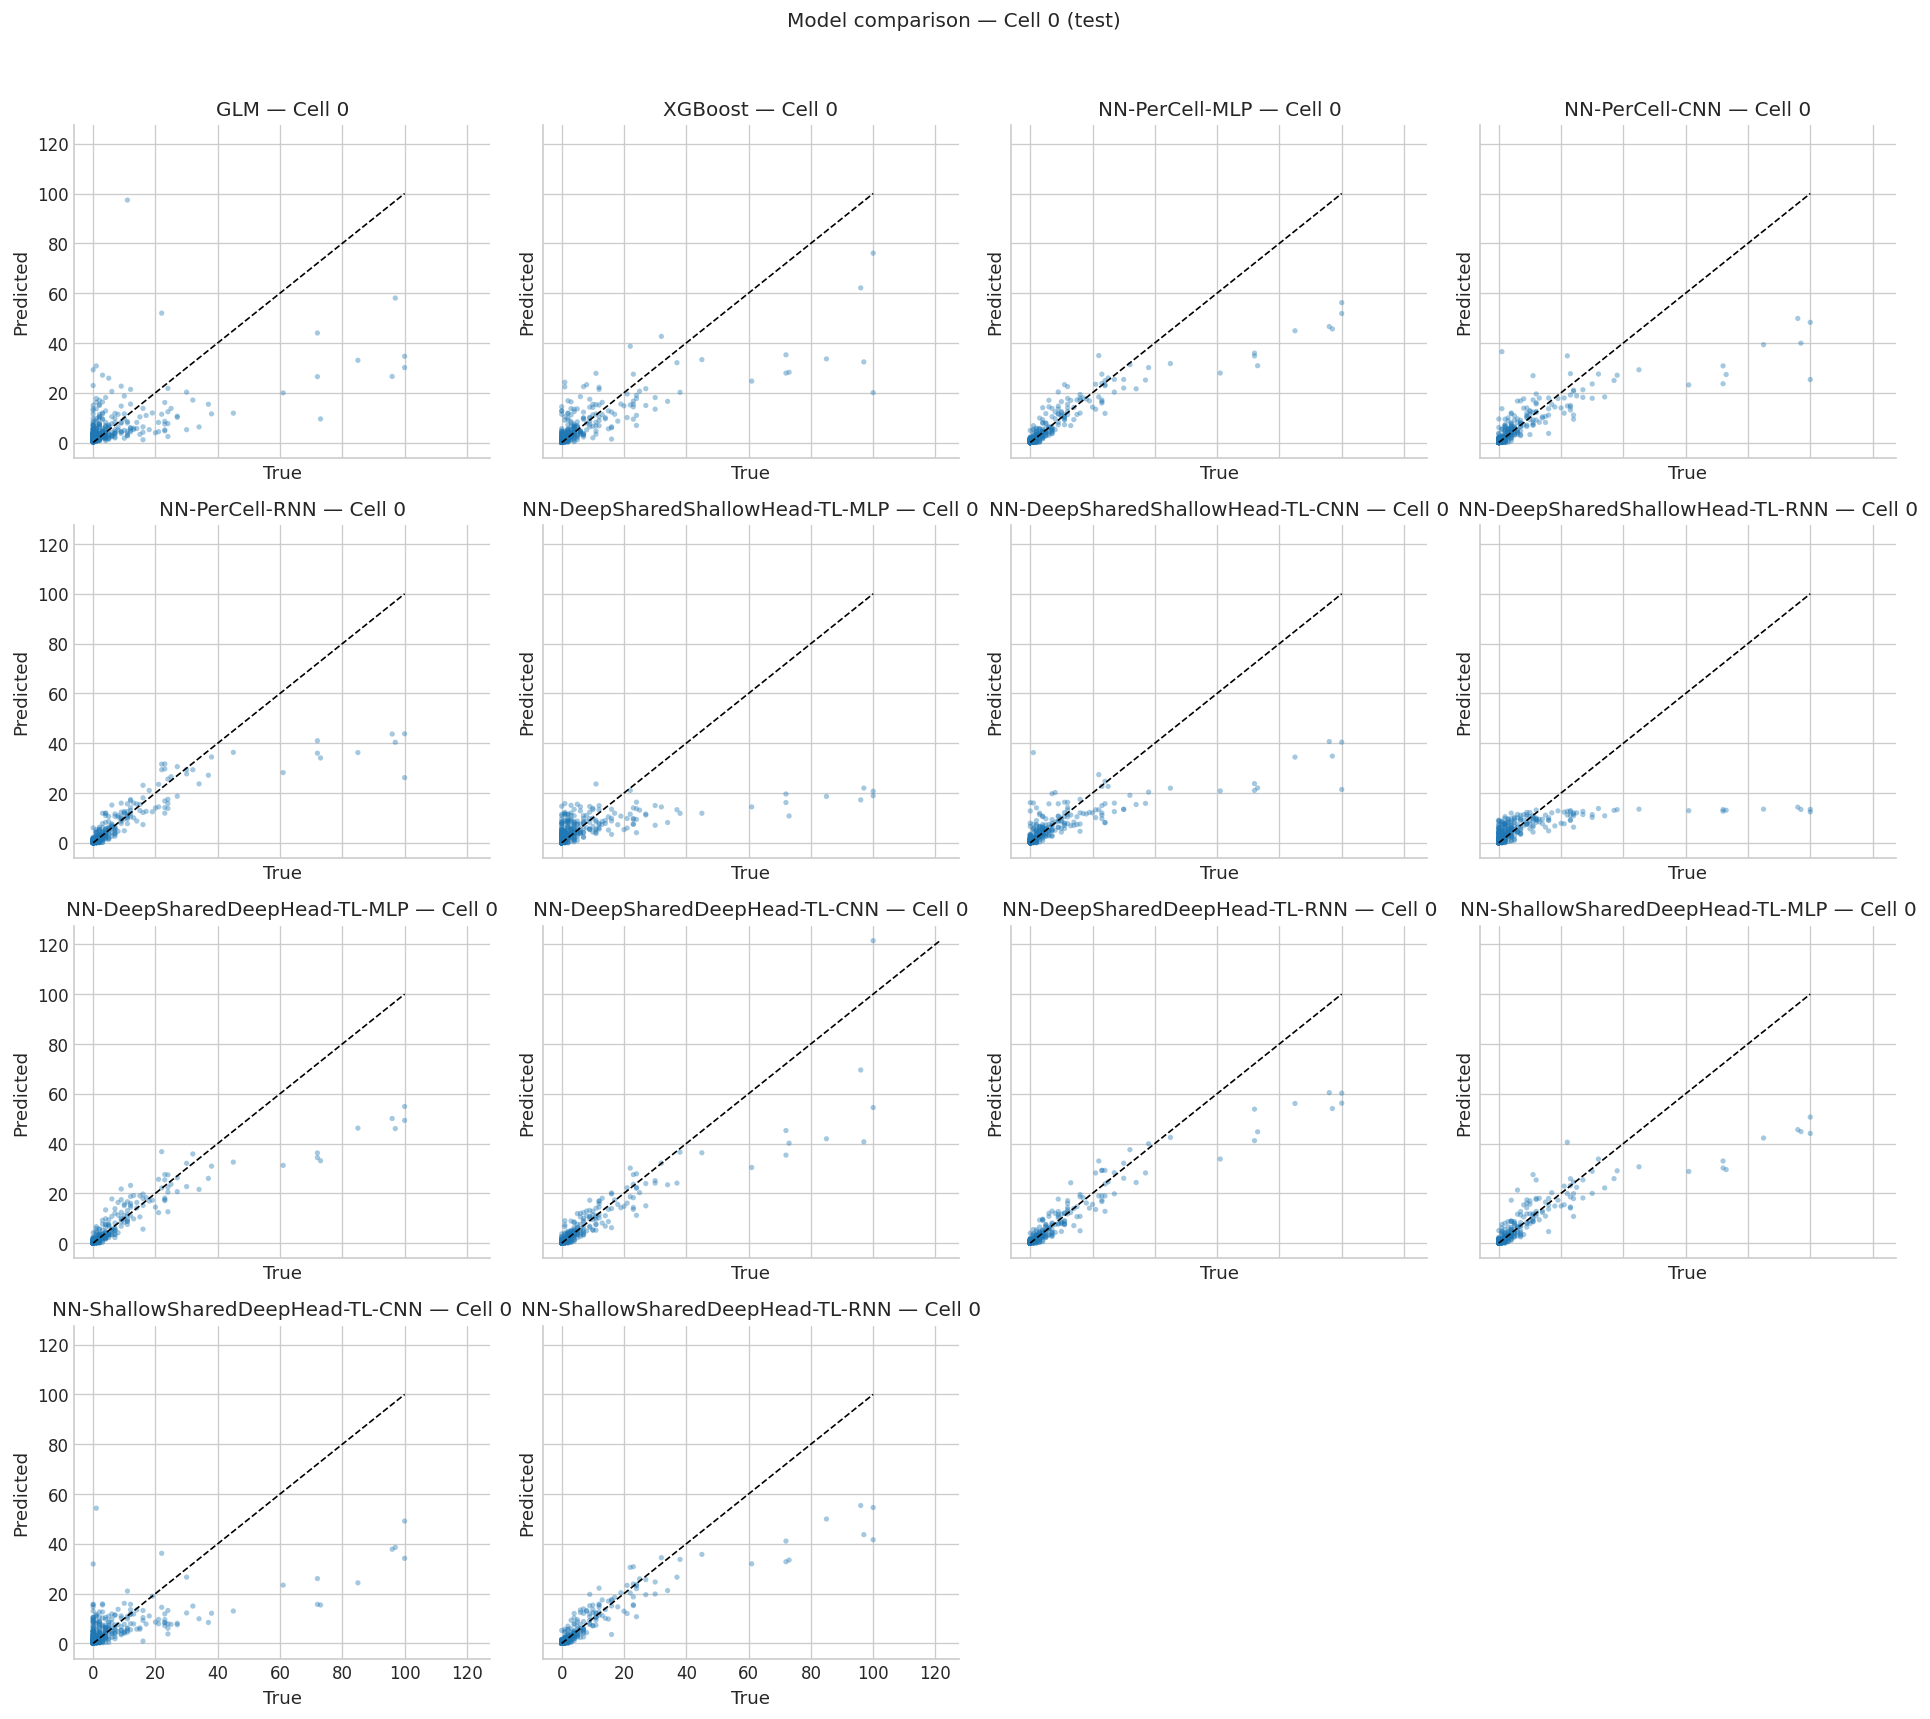

In [77]:
compare_models_for_cell(model_results_gs, cell=0, split="test")

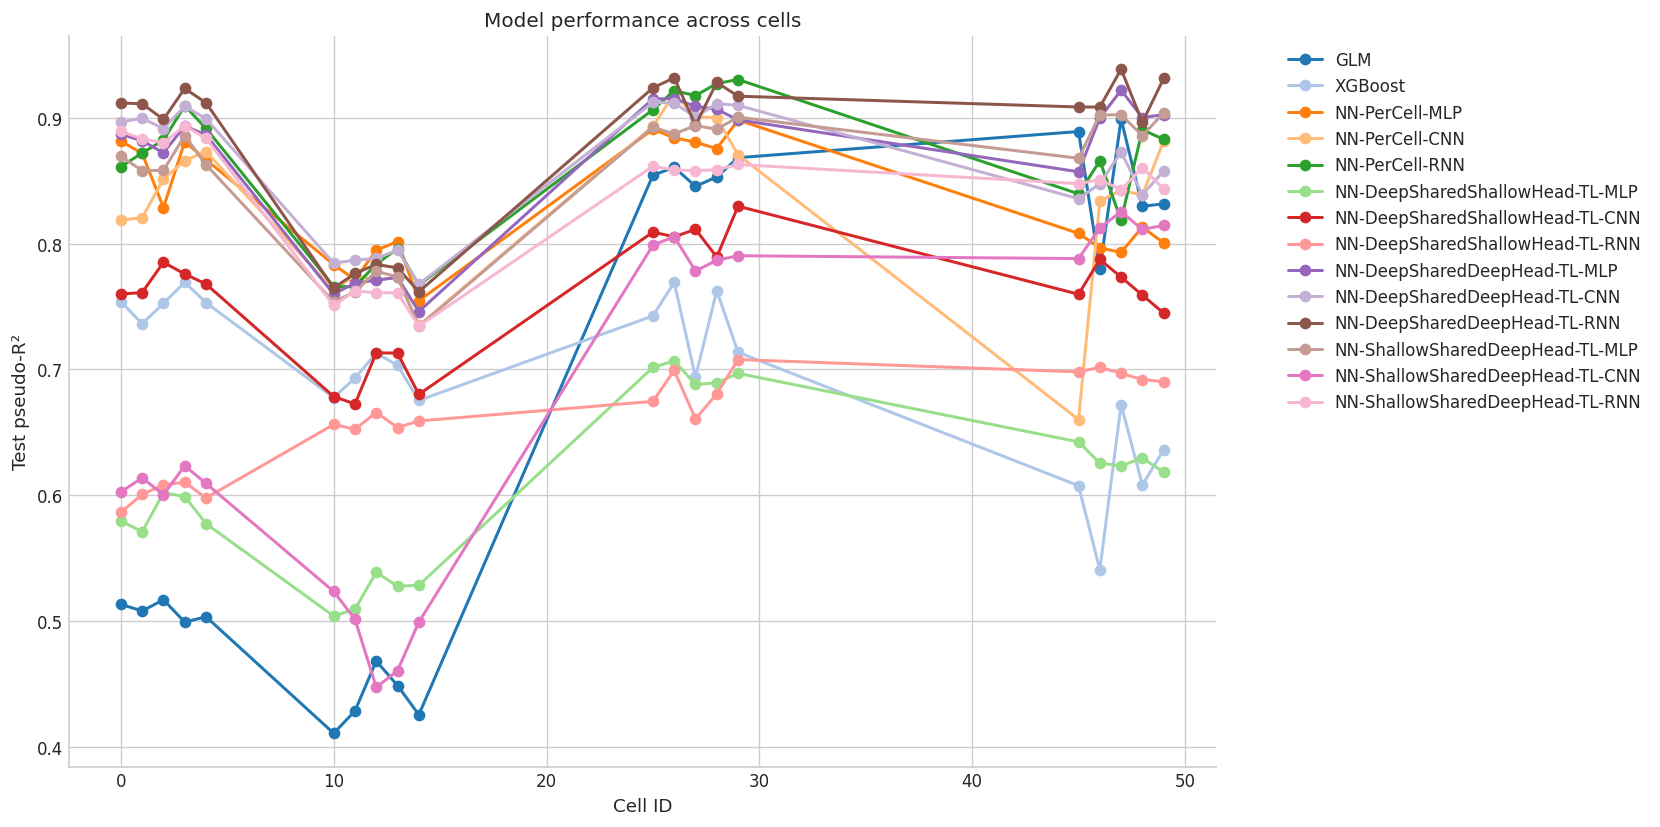

In [78]:
compare_r2_across_cells(model_results_gs, split="test")

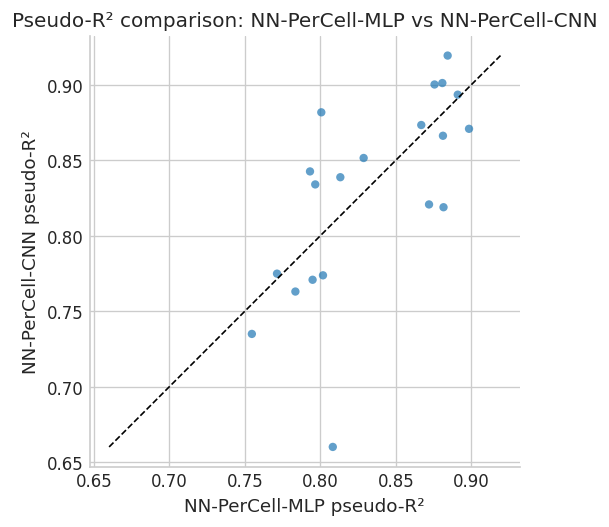

In [79]:
compare_models_pairwise_r2(
    model_results_gs,
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
)

In [80]:
# No-grid-search results for all models
model_results_nogs = [
    (glm_nogs_results["results"], "GLM (No GS)"),
    (xgboost_nogs_results["results"], "XGBoost (No GS)"),
    (percell_results["MLP"]["NoGS"]["results"], "NN-PerCell-MLP (No GS)"),
    (percell_results["CNN"]["NoGS"]["results"], "NN-PerCell-CNN (No GS)"),
    (percell_results["RNN"]["NoGS"]["results"], "NN-PerCell-RNN (No GS)"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP (No GS)",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN (No GS)",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN (No GS)",
    ),
]

cells_nogs = sorted(glm_nogs_results["results"].keys())

In [81]:
data_rows = []
for cell in cells_nogs:
    row = {"cell": cell}
    for results, name in model_results_nogs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_nogs = pd.DataFrame(data_rows)
df_test_perf_nogs

,cell,GLM (No GS),XGBoost (No GS),NN-PerCell-MLP (No GS),NN-PerCell-CNN (No GS),NN-PerCell-RNN (No GS),NN-DeepSharedShallowHead-TL-MLP (No GS),NN-DeepSharedShallowHead-TL-CNN (No GS),NN-DeepSharedShallowHead-TL-RNN (No GS),NN-DeepSharedDeepHead-TL-MLP (No GS),NN-DeepSharedDeepHead-TL-CNN (No GS),NN-DeepSharedDeepHead-TL-RNN (No GS),NN-ShallowSharedDeepHead-TL-MLP (No GS),NN-ShallowSharedDeepHead-TL-CNN (No GS),NN-ShallowSharedDeepHead-TL-RNN (No GS)
0,0.0,0.495828,0.787478,0.893040,0.867123,0.870030,0.557775,0.661593,0.307851,0.815853,0.838093,0.616135,0.625056,0.298010,0.598782
1,1.0,0.491330,0.776923,0.860431,0.878646,0.877143,0.574929,0.674349,0.346858,0.803484,0.839723,0.593509,0.608398,0.296483,0.610587
2,2.0,0.487759,0.777255,0.898519,0.862067,0.879220,0.581005,0.658327,0.315764,0.816972,0.818765,0.607160,0.616302,0.289123,0.629241
3,3.0,0.481392,0.781882,0.878529,0.875266,0.885301,0.571394,0.678459,0.327624,0.821874,0.839446,0.609852,0.635108,0.299197,0.626014
4,4.0,0.472272,0.763104,0.828087,0.874012,0.870070,0.578282,0.655112,0.326243,0.811906,0.838727,0.626790,0.639715,0.292417,0.618771
5,10.0,0.413206,0.690789,0.787267,0.744805,0.761073,0.528661,0.488682,0.294989,0.627647,0.677351,0.439712,0.596561,0.224187,0.615684
6,11.0,0.439885,0.710068,0.783759,0.765926,0.773868,0.529778,0.512873,0.368117,0.644051,0.699248,0.442184,0.596437,0.225918,0.613831
7,12.0,0.454806,0.729184,0.806965,0.769659,0.789701,0.551791,0.435798,0.340028,0.659423,0.697218,0.435094,0.628132,0.202013,0.587756
8,13.0,0.438039,0.709677,0.800454,0.758884,0.787117,0.543946,0.546490,0.335873,0.648914,0.698184,0.444723,0.608494,0.210204,0.591160
9,14.0,0.431220,0.694672,0.756711,0.741534,0.764318,0.551588,0.465409,0.347554,0.634661,0.671949,0.432062,0.604790,0.227848,0.591019


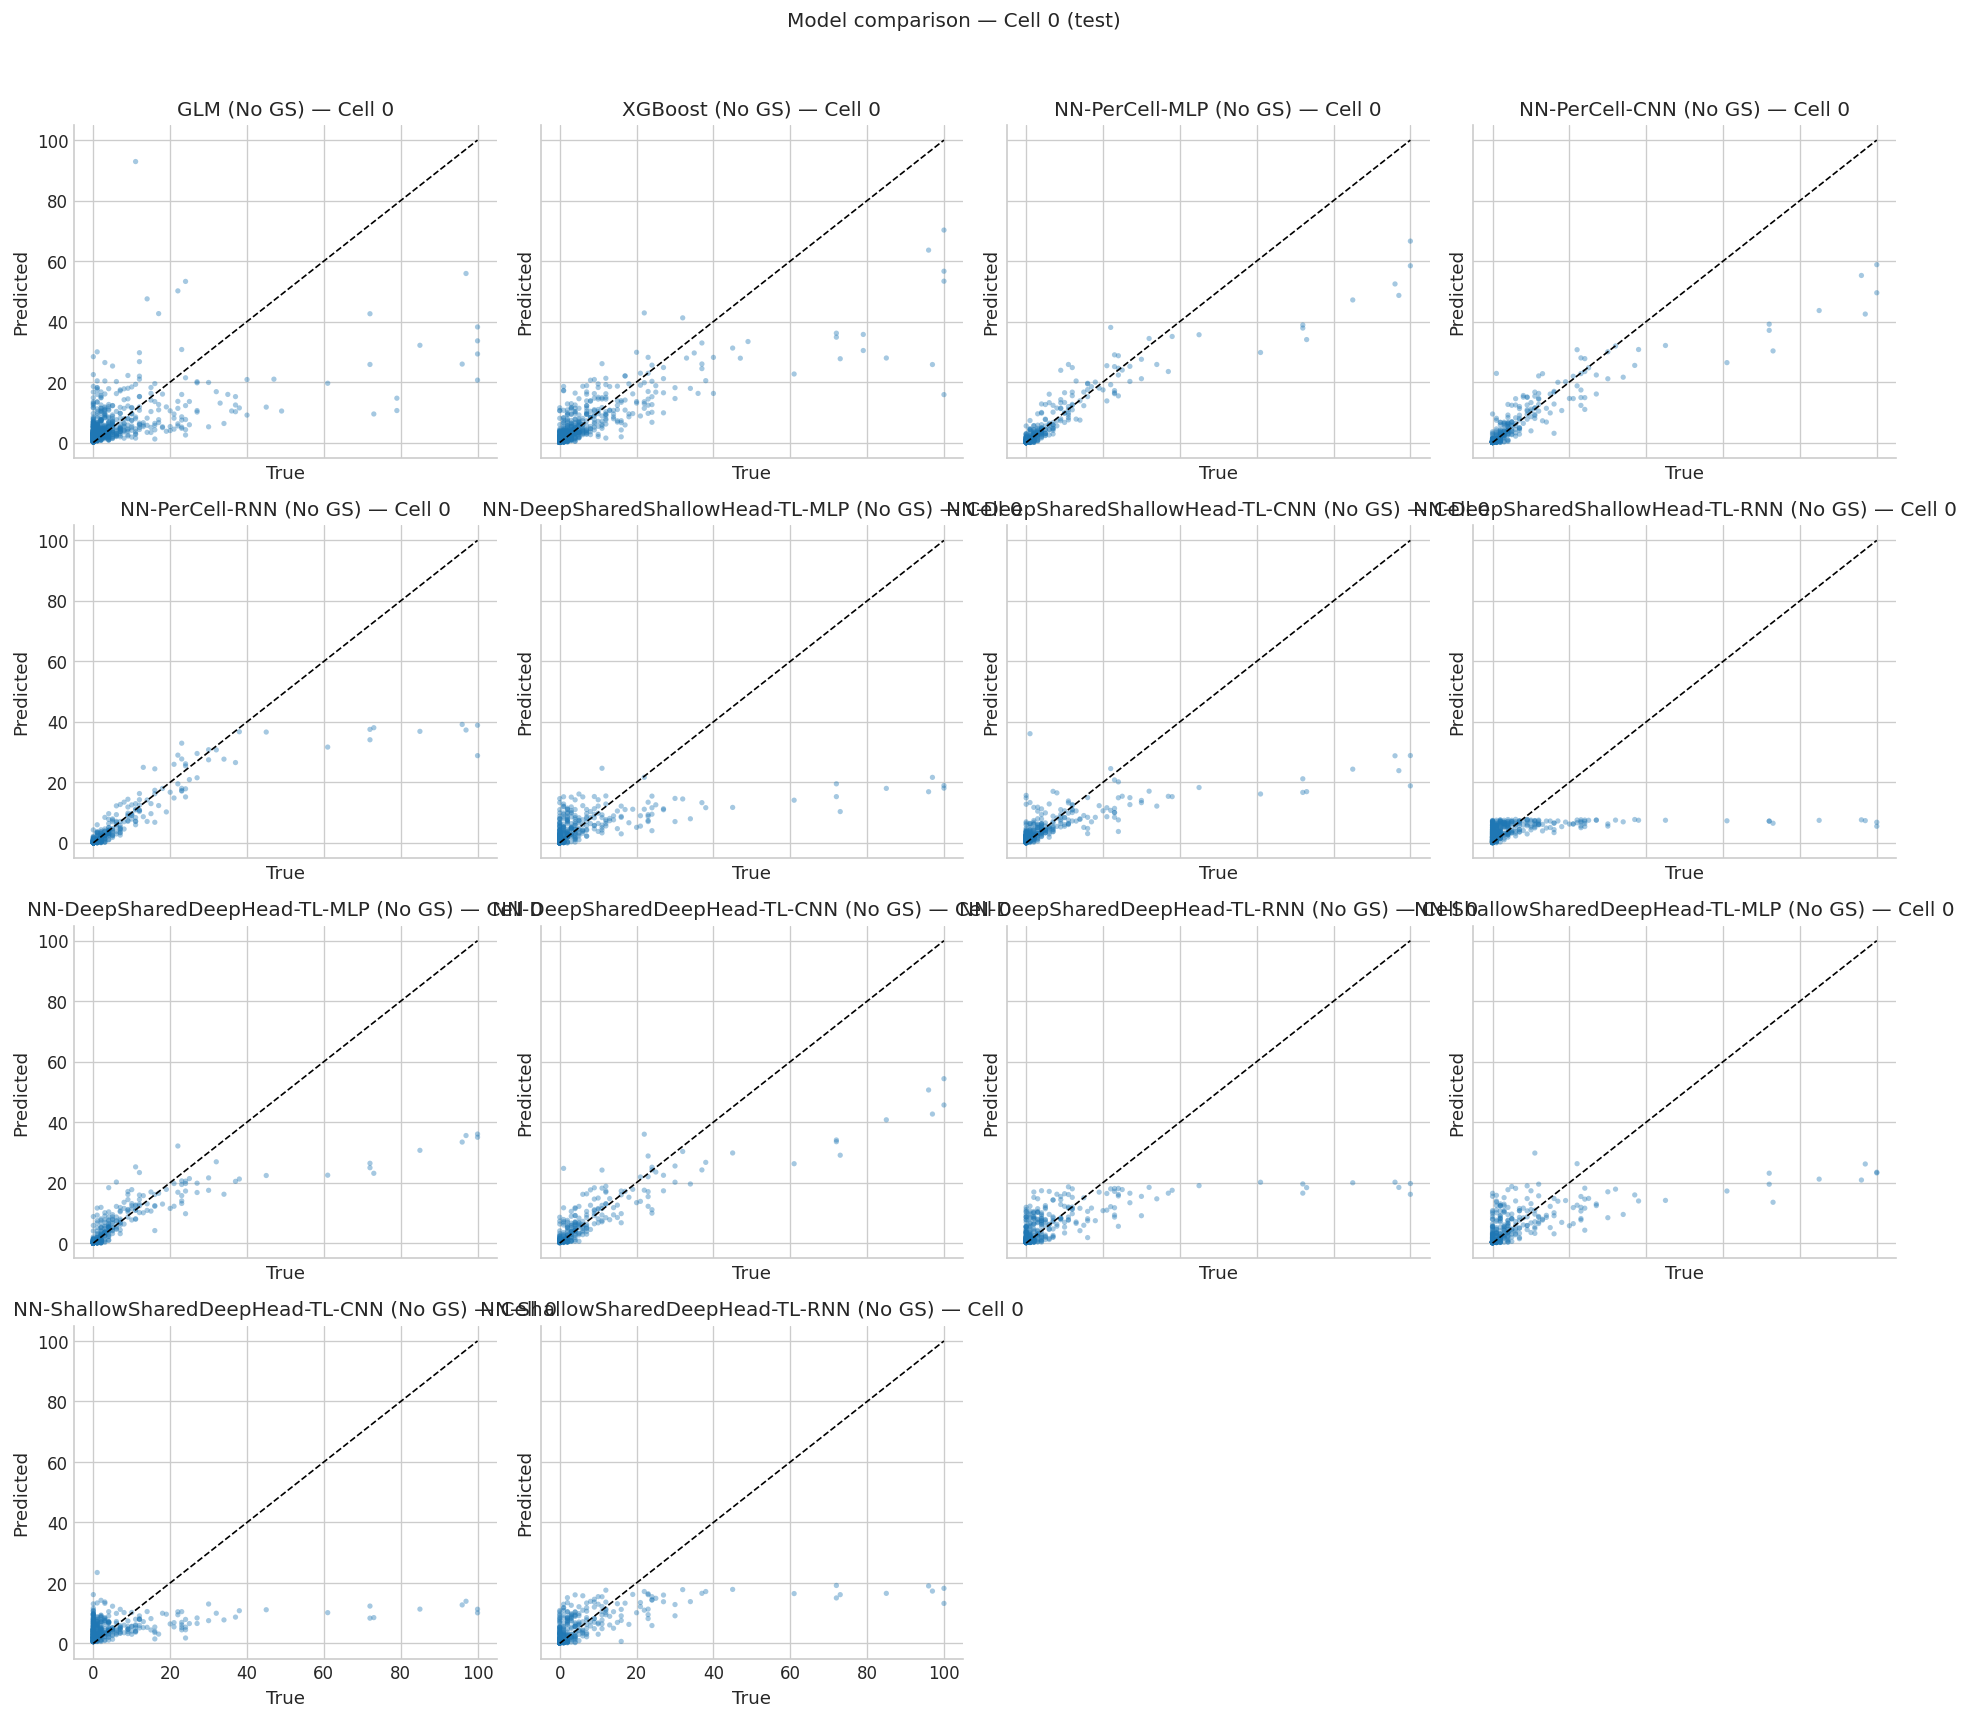

In [82]:
compare_models_for_cell(model_results_nogs, cell=0, split="test")

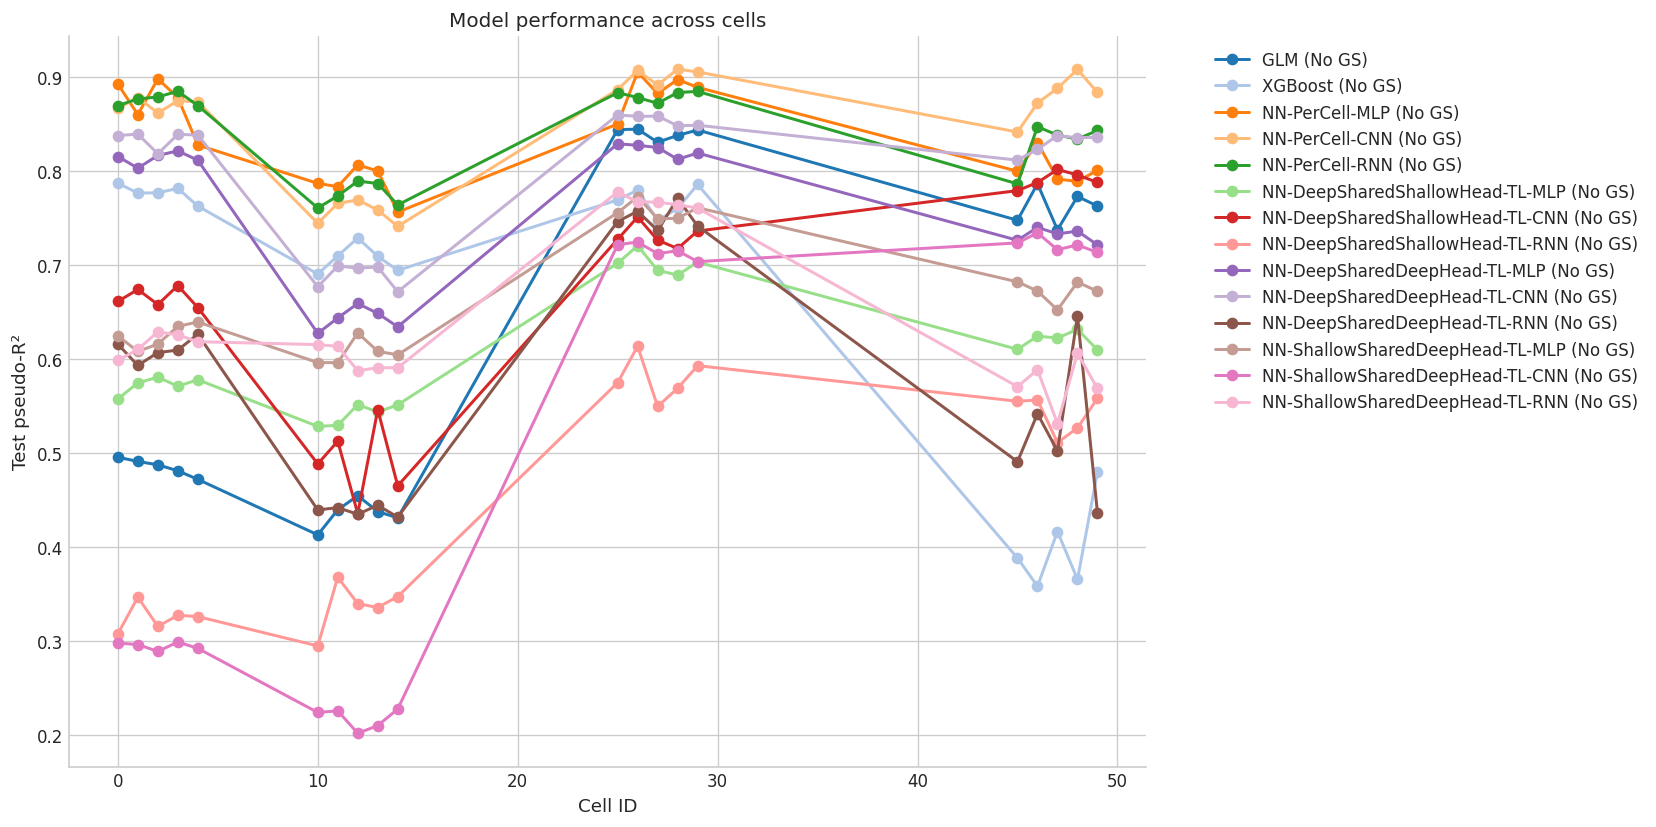

In [83]:
compare_r2_across_cells(model_results_nogs, split="test")

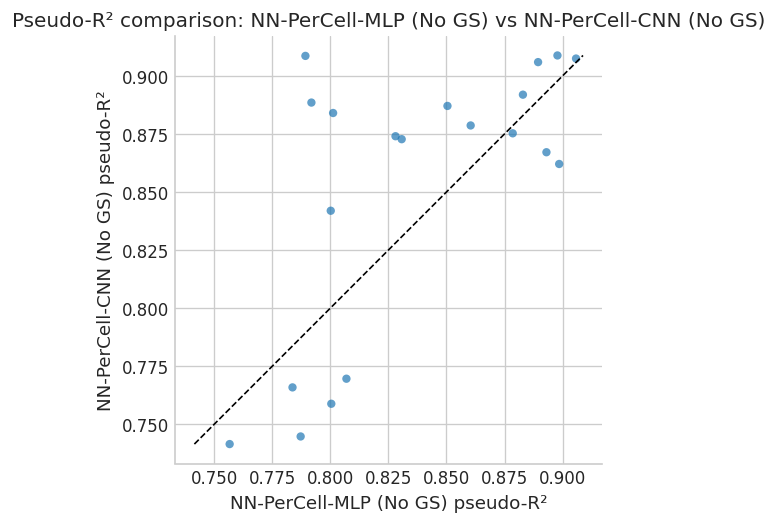

In [84]:
compare_models_pairwise_r2(
    model_results_nogs,
    "NN-PerCell-MLP (No GS)",
    "NN-PerCell-CNN (No GS)",
)

In [85]:
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
)
print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    print(f"  {p}")

Generated 112 plots
  ..\resources\results\simulated\journal\pairwise_NN-DeepSharedDeepHead-TL-RNN_vs_NN-ShallowSharedDeepHead-TL-CNN.png
  ..\resources\results\simulated\journal\pairwise_NN-DeepSharedDeepHead-TL-RNN_vs_NN-ShallowSharedDeepHead-TL-RNN.png
  ..\resources\results\simulated\journal\pairwise_NN-ShallowSharedDeepHead-TL-MLP_vs_NN-ShallowSharedDeepHead-TL-CNN.png
  ..\resources\results\simulated\journal\pairwise_NN-ShallowSharedDeepHead-TL-MLP_vs_NN-ShallowSharedDeepHead-TL-RNN.png
  ..\resources\results\simulated\journal\pairwise_NN-ShallowSharedDeepHead-TL-CNN_vs_NN-ShallowSharedDeepHead-TL-RNN.png
